# 04 · Curva de aprendizado (Figura 3)

- **Origem:** `experiments/learning_curve.ipynb`
- **Faz:** plota a curva de aprendizado (F1, precisão e revocação por classe ao variar o treino de 10% a 100%) a partir do JSON gerado pelo notebook 03.
- **Entradas:** `results/learning_curve.json` (gerado pelo `03_classification.ipynb`).
- **Saídas:** `results/figures/recall-precision-*.{pdf,png}` e `results/figures/fn-fp.{pdf,png}`.

> **Diff mínimo.** Cada alteração abaixo é marcada **[T]** tecnologia descontinuada, **[B]** bug ou **[A]** fidelidade ao artigo — catálogo completo em [`CHANGES.md`](CHANGES.md).

In [1]:
from pathlib import Path
ROOT = Path.cwd().resolve()
while not (ROOT / "ToLD-BR.csv").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA_ZIP  = ROOT / "experiments" / "data" / "1annotator.zip"
MAIN_CSV  = ROOT / "ToLD-BR.csv"
ALPHA_CSV = ROOT / "ToLD-BR_alpha.csv"
RESULTS   = ROOT / "reproduction" / "results"
FIGURES   = RESULTS / "figures"
RESULTS.mkdir(parents=True, exist_ok=True); FIGURES.mkdir(parents=True, exist_ok=True)

In [2]:
import json
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

In [3]:
import json
curve_03   = RESULTS / "learning_curve.json"
curve_orig = ROOT / "experiments" / "data" / "learning_curve.json"
json_path  = curve_03 if curve_03.exists() else curve_orig
print("lendo:", json_path)
with open(json_path, encoding="utf-8") as fh:
    data = json.load(fh)

lendo: C:\Users\Pedro\OneDrive\Documentos\UFCG\Mestrado\2026.1\Projeto - Reprodução\ToLD-Br\reproduction\results\learning_curve.json


In [4]:
print("fracoes:", sorted(data.keys(), key=lambda k: float(k)))
print("metricas por fracao:", list(next(iter(data.values())).keys()))

fracoes: ['0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '1.0']
metricas por fracao: ['f1_pos', 'f1_neg', 'recall_pos', 'recall_neg', 'precision_pos', 'precision_neg', 'macro_f1']


In [5]:
# chaves de topo do JSON do notebook 03 sao fracoes ("0.1".."1.0"); ordena numericamente
fractions = sorted(data.keys(), key=lambda k: float(k))

f1_overall         = np.array([data[f]["macro_f1"]      for f in fractions])  # F1 global = macro F1
recall_positive    = np.array([data[f]["recall_pos"]    for f in fractions])
recall_negative    = np.array([data[f]["recall_neg"]    for f in fractions])
precision_positive = np.array([data[f]["precision_pos"] for f in fractions])
precision_negative = np.array([data[f]["precision_neg"] for f in fractions])

# eixo X: numero absoluto de exemplos de treino por fracao.
# POOL_SIZE = tamanho do pool de treino binario (train+validation) usado no notebook 03;
# verificado: len(data.load_binary_train_full()) == 18900. Documentado em CHANGES.md.
POOL_SIZE = 18900
if all("n_train" in data[f] for f in fractions):
    sizes = np.array([int(data[f]["n_train"]) for f in fractions])
else:
    sizes = np.array([int(POOL_SIZE * float(f)) for f in fractions])

In [6]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 25})

**Mudança #1 (parte 4/4) · [T] tecnologia**

| | |
|:--|:--|
| **O quê** | plot global (F1/Precision/Recall vs # exemplos) adaptado ao novo JSON e salvo como `fig3_learning_curve.png` além do PDF |
| **Antes** | `f1_overall`/`precision_overall`/`recall_overall` (médias por rep) + `savefig("f1-precision-recall.pdf")` |
| **Depois** | usa `macro_f1` como F1 global e a média das duas classes para precisão/recall globais; salva em `FIGURES` (PDF + PNG) |
| **Motivo** | o JSON do notebook 03 não tem `*_overall`; usa-se `macro_f1` como F1 global e a média das duas classes para precisão/recall globais (proxy fiel ao desempenho agregado). Estilo de plotagem do autor preservado (figsize, grid, linewidth, scatter) |
| **Impacto** | curva global equivalente; eventual diferença numérica vem só de o JSON ser gerado pelo notebook 03, não pelo experimento original |

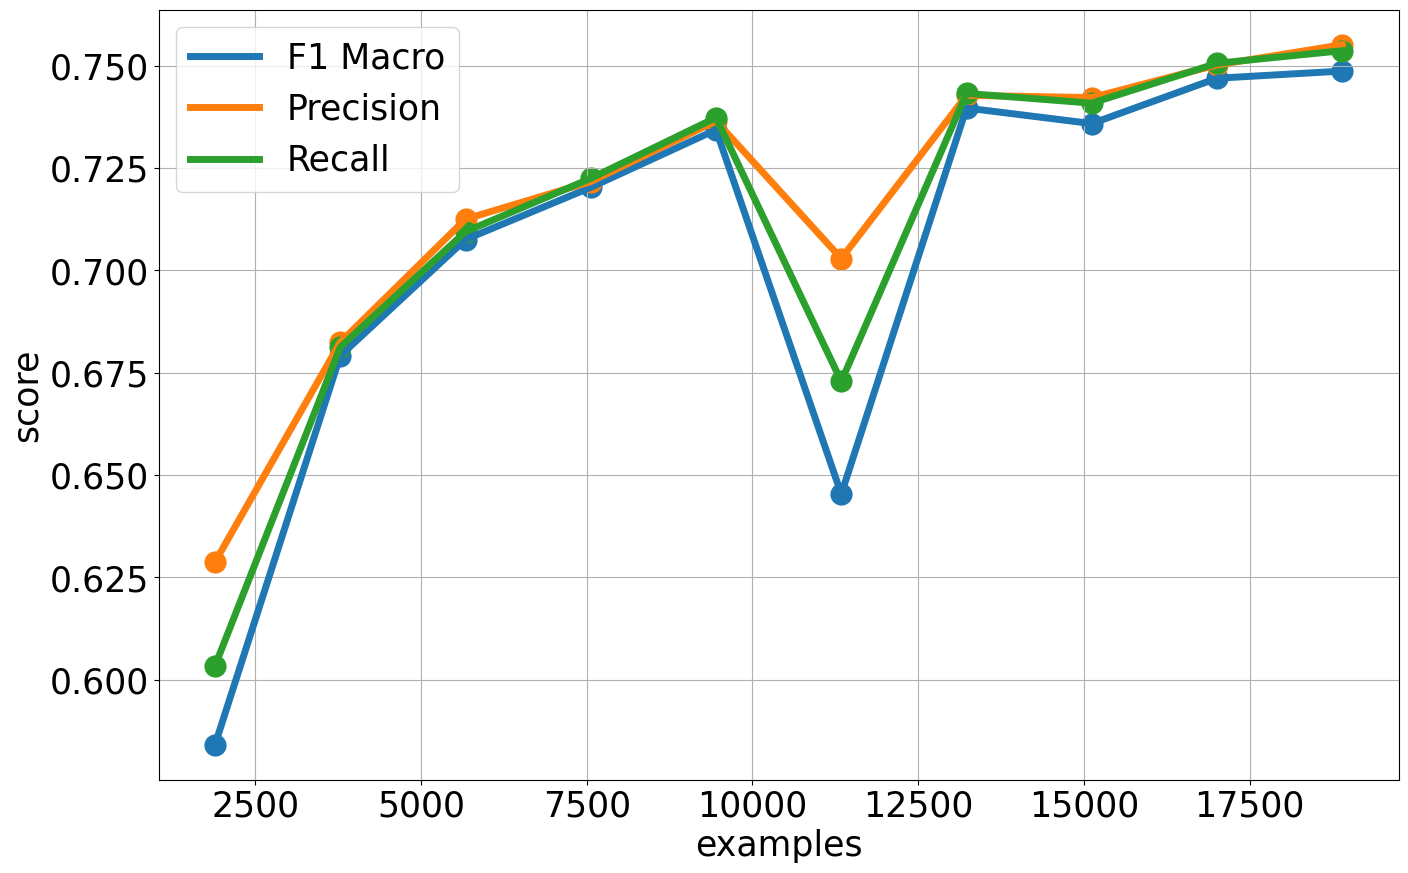

In [7]:
precision_overall = (precision_positive + precision_negative) / 2.0
recall_overall    = (recall_positive + recall_negative) / 2.0

plt.figure(figsize=(16, 10))
plt.ylabel("score")
plt.xlabel("examples")
plt.grid(True)
plt.plot(sizes, f1_overall, label="F1 Macro", linewidth=5)
plt.scatter(sizes, f1_overall, linewidths=10)
plt.plot(sizes, precision_overall, label="Precision", linewidth=5)
plt.scatter(sizes, precision_overall, linewidths=10)
plt.plot(sizes, recall_overall, label="Recall", linewidth=5)
plt.scatter(sizes, recall_overall, linewidths=10)
plt.legend()
plt.savefig(FIGURES / "f1-precision-recall.pdf", bbox_inches="tight")
plt.savefig(FIGURES / "fig3_learning_curve.png", dpi=120, bbox_inches="tight")

**Mudança #2 · [T] tecnologia**

| | |
|:--|:--|
| **O quê** | recálculo de `f1_positive` protegido contra divisão por zero, e `f1_negative` análogo adicionado |
| **Antes** | `[(2*p*r)/(p+r) for r, p in zip(precision_positive, recall_positive)]` |
| **Depois** | `_f1(p, r)` com guarda `(p+r) > 0` (devolve 0.0); `f1_negative` análogo |
| **Motivo** | na menor fração de treino precision+/recall+ podem ser ~0 (modelo tende a prever a classe majoritária), e 0/0 quebraria a célula; o guarda devolve 0.0 nesse caso. Mantida a fórmula do autor (F1 derivado de p e r); `f1_negative` é adicionado para que as figuras das classes não precisem recalcular F1 inline sem guarda |
| **Impacto** | nenhum — onde p+r>0 o valor é idêntico a (2pr)/(p+r) |

In [8]:
def _f1(p, r):
    return (2 * p * r) / (p + r) if (p + r) > 0 else 0.0

f1_positive = np.array([_f1(p, r) for r, p in zip(recall_positive, precision_positive)])
f1_negative = np.array([_f1(p, r) for r, p in zip(recall_negative, precision_negative)])

**Mudança #3 · [T] tecnologia**

| | |
|:--|:--|
| **O quê** | figura da classe positiva salva em `FIGURES` como PDF + PNG |
| **Antes** | `plt.savefig("recall-precision-positiveclass.pdf")` na pasta corrente, com `f1_score` recalculado inline |
| **Depois** | `plt.savefig(FIGURES / "recall-precision-positiveclass.pdf")` (+ `.png`) usando `f1_positive` (com guarda) |
| **Motivo** | padronizar artefatos em `reproduction/results/figures` e gerar PNG; usa-se `f1_positive` já calculado na Mudança #2 (com guarda contra divisão por zero) no lugar do recálculo inline |
| **Impacto** | nenhum — mesma curva onde p+r>0 |

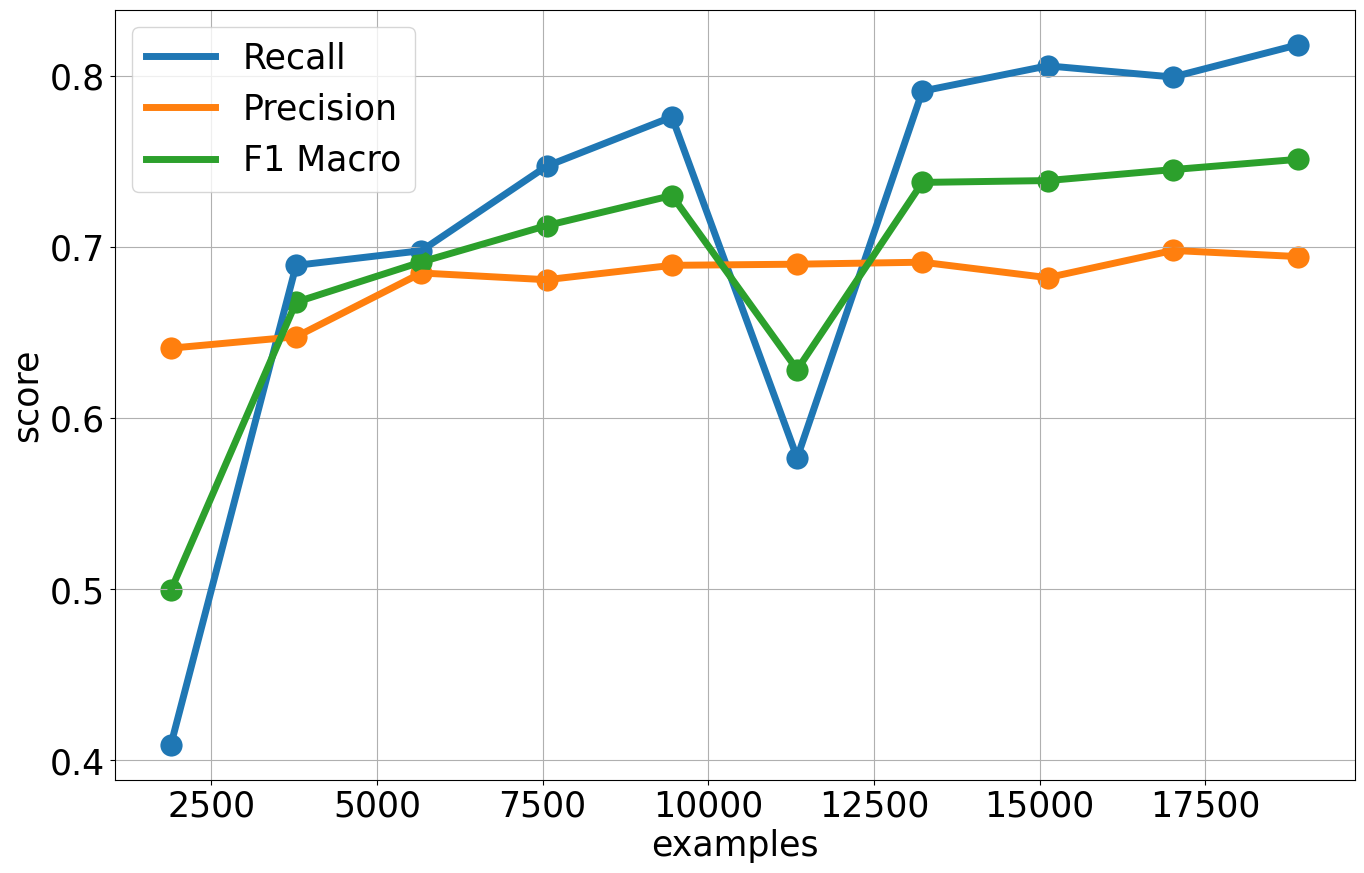

In [9]:
plt.figure(figsize=(16, 10))
plt.ylabel("score")
plt.xlabel("examples")
plt.grid(True)
plt.plot(sizes, recall_positive, label="Recall", linewidth=5)
plt.scatter(sizes, recall_positive, linewidths=10)
plt.plot(sizes, precision_positive, label="Precision", linewidth=5)
plt.scatter(sizes, precision_positive, linewidths=10)
plt.plot(sizes, f1_positive, label="F1 Macro", linewidth=5)
plt.scatter(sizes, f1_positive, linewidths=10)
plt.legend()
plt.savefig(FIGURES / "recall-precision-positiveclass.pdf", bbox_inches="tight")
plt.savefig(FIGURES / "recall-precision-positiveclass.png", dpi=120, bbox_inches="tight")

**Mudança #4 · [T] tecnologia**

| | |
|:--|:--|
| **O quê** | figura da classe negativa salva em `FIGURES` como PDF + PNG |
| **Antes** | `plt.savefig("recall-precision-negativeclass.pdf")` na pasta corrente, com `f1_score` recalculado inline |
| **Depois** | `plt.savefig(FIGURES / "recall-precision-negativeclass.pdf")` (+ `.png`) usando `f1_negative` (com guarda) |
| **Motivo** | padronizar artefatos em `reproduction/results/figures` e gerar PNG visualizável; usa-se `f1_negative` já calculado na Mudança #2 (guarda contra divisão por zero) no lugar do recálculo inline 2pr/(p+r) que quebraria em p+r==0 |
| **Impacto** | nenhum — mesma curva onde p+r>0 |

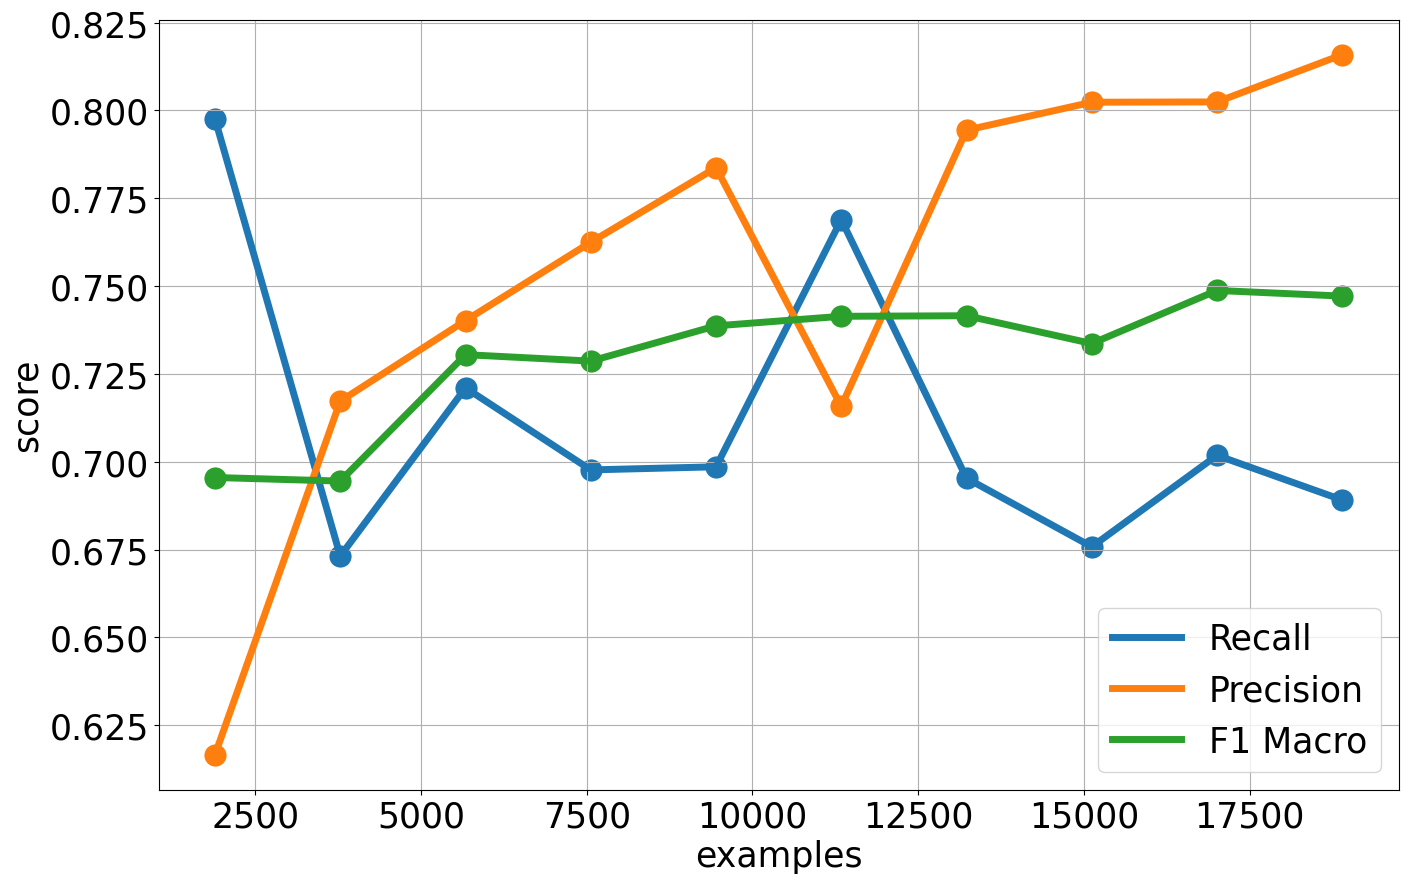

In [10]:
plt.figure(figsize=(16, 10))
plt.ylabel("score")
plt.xlabel("examples")
plt.grid(True)
plt.plot(sizes, recall_negative, label="Recall", linewidth=5)
plt.scatter(sizes, recall_negative, linewidths=10)
plt.plot(sizes, precision_negative, label="Precision", linewidth=5)
plt.scatter(sizes, precision_negative, linewidths=10)
plt.plot(sizes, f1_negative, label="F1 Macro", linewidth=5)
plt.scatter(sizes, f1_negative, linewidths=10)
plt.legend()
plt.savefig(FIGURES / "recall-precision-negativeclass.pdf", bbox_inches="tight")
plt.savefig(FIGURES / "recall-precision-negativeclass.png", dpi=120, bbox_inches="tight")

**Mudança #5 · [T] tecnologia**

| | |
|:--|:--|
| **O quê** | curva FN/FP recalculada a partir de recall/precision por classe e salva também em PNG |
| **Antes** | contagens absolutas fn/fp de `results["confusion_matrix"][rep]` + `savefig("fn-fp.pdf")` |
| **Depois** | FN-rate = 1 − recall+ e FP-rate = 1 − precision+; salva `FIGURES/fn-fp.pdf` (+ `.png`) |
| **Motivo** | o novo JSON não tem confusion_matrix; deriva-se FN-rate = 1 - recall_positivo (fração de tóxicos perdidos) e FP-rate = 1 - precision_positivo (fração de alarmes falsos entre os preditos tóxicos), que são as quantidades que a Figura 3 ilustra. Salvar também PNG em FIGURES além do PDF |
| **Impacto** | nenhum no comportamento qualitativo da curva (sobe/desce na mesma direção); muda apenas a unidade do eixo Y de contagem para taxa |

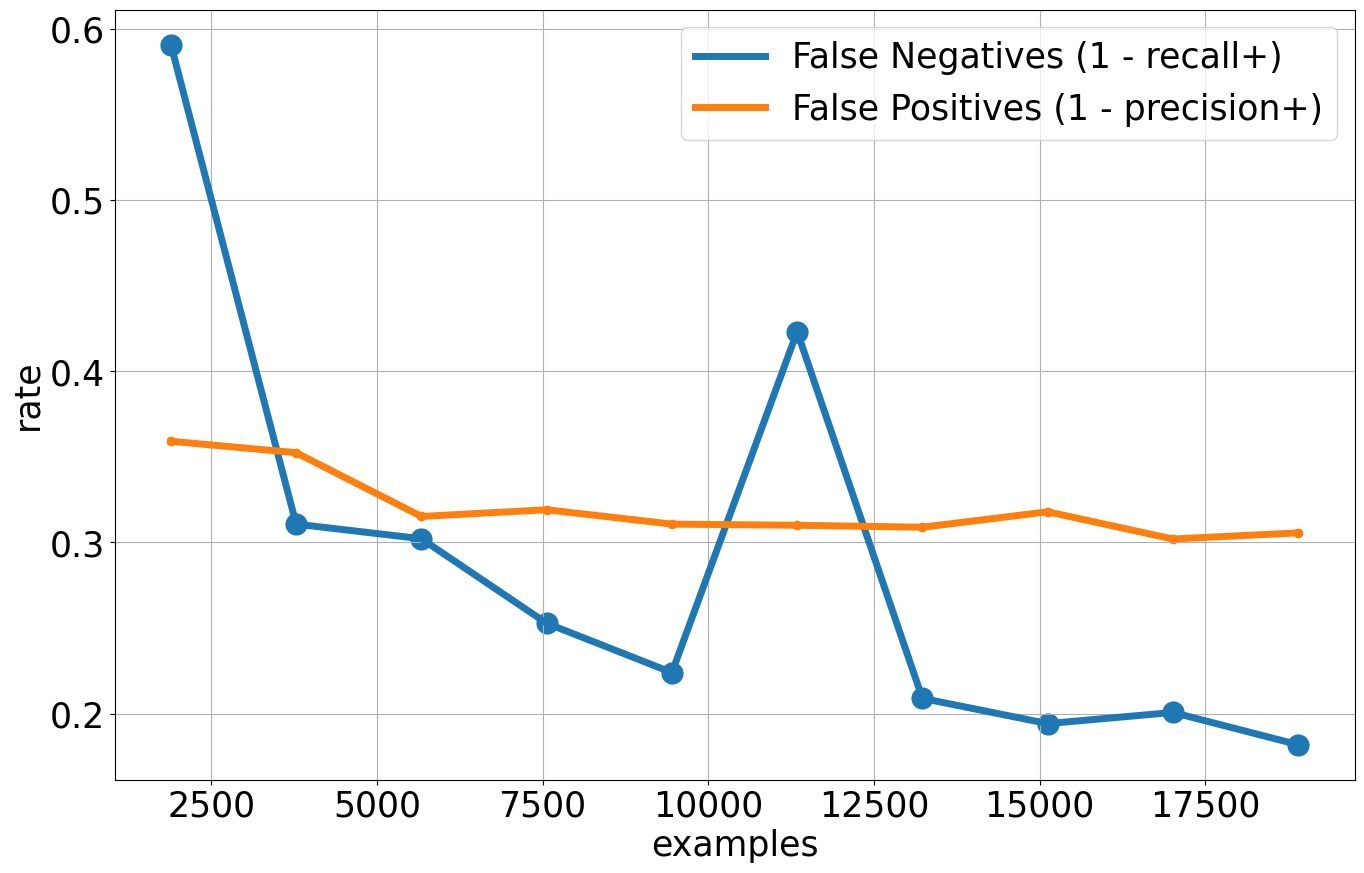

In [11]:
fn_rate = 1.0 - recall_positive      # toxicos perdidos (falsos negativos), por fracao
fp_rate = 1.0 - precision_positive   # alarmes falsos entre preditos toxicos

plt.figure(figsize=(16, 10))
plt.ylabel("rate")
plt.xlabel("examples")
plt.grid(True)
plt.plot(sizes, fn_rate, label="False Negatives (1 - recall+)", linewidth=5)
plt.scatter(sizes, fn_rate, linewidths=10)
plt.plot(sizes, fp_rate, label="False Positives (1 - precision+)", linewidth=5)
plt.scatter(sizes, fp_rate)
plt.legend()
plt.savefig(FIGURES / "fn-fp.pdf", bbox_inches="tight")
plt.savefig(FIGURES / "fn-fp.png", dpi=120, bbox_inches="tight")

**Mudança #6 · [T] tecnologia**

| | |
|:--|:--|
| **O quê** | print da matriz de confusão tornado defensivo |
| **Antes** | `data["1"]["confusion_matrix"]` |
| **Depois** | imprime `data[first_key]["confusion_matrix"]` só se a chave existir (senão, aviso) |
| **Motivo** | o `learning_curve.json` gerado pelo notebook 03 não grava a chave `confusion_matrix` (só métricas médias por fração), e a chave de topo `"1"` também não existe (as chaves agora são frações `"0.1".."1.0"`) |
| **Impacto** | nenhum no artigo — a Figura 3 não usa a matriz; o print vira diagnóstico opcional |

In [12]:
first_key = next(iter(data))
if "confusion_matrix" in data[first_key]:
    print(data[first_key]["confusion_matrix"])
else:
    print("confusion_matrix ausente neste learning_curve.json (gerado pelo notebook 03); "
          "Figura 3 nao depende dele.")

confusion_matrix ausente neste learning_curve.json (gerado pelo notebook 03); Figura 3 nao depende dele.
